# STT Confidence: Deepgram Nova-3 vs Genesys r2d2

Generates a standalone confidence bar chart comparing matched-pair and all-transcript median confidence.
Data sources are the same raw files used by `cross_system_latency-02-EB-RESULTS.ipynb`.

In [1]:
import json
import statistics
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")

REPO_ROOT = Path("..").resolve()
DEEPGRAM_RESULTS_DIR = (REPO_ROOT / ".." / "poc-deepgram" / "results").resolve()
NOTIF_EVENTS_DIR = (REPO_ROOT / "conversation_events").resolve()
EB_EVENTS_DIR = (REPO_ROOT / "EventBridge" / "conversation_events").resolve()
OUTPUT_DIR = REPO_ROOT / "analysis_results" / "cross_system_eb_p99"
SAVE_DPI = 300
NUM_RECENT = 6

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {OUTPUT_DIR}")

Output dir: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system_eb_p99


In [2]:
# --- File matching (same logic as 02-EB-RESULTS) ---
from datetime import datetime


def get_dg_time_range(path):
    data = json.loads(path.read_text())
    session = data.get("session", {})
    started = session.get("started_at", "")
    ended = session.get("ended_at", "")
    start_ts = datetime.fromisoformat(started).timestamp() if started else 0
    end_ts = datetime.fromisoformat(ended).timestamp() if ended else float("inf")
    return start_ts, end_ts


def get_jsonl_time_range(path):
    lines = path.read_text().strip().splitlines()
    if not lines:
        return 0, 0
    timestamps = [json.loads(line)["receivedAt"] for line in lines]
    return min(timestamps), max(timestamps)


dg_files = sorted(DEEPGRAM_RESULTS_DIR.glob("*.json"), key=lambda f: f.stat().st_mtime, reverse=True)[:NUM_RECENT]
notif_files = sorted(NOTIF_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)[:NUM_RECENT]
eb_files = sorted(EB_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)[:NUM_RECENT]

# Match Deepgram <-> Notifications by time overlap
notif_matched = []
used_notif = set()
for dg_path in dg_files:
    dg_start, dg_end = get_dg_time_range(dg_path)
    best_idx, best_overlap = None, 0
    for j, nf in enumerate(notif_files):
        if j in used_notif:
            continue
        nf_start, nf_end = get_jsonl_time_range(nf)
        overlap = max(0, min(dg_end, nf_end) - max(dg_start, nf_start))
        if overlap > best_overlap:
            best_overlap = overlap
            best_idx = j
    if best_idx is not None:
        notif_matched.append((dg_path, notif_files[best_idx]))
        used_notif.add(best_idx)

# Match Notifications <-> EventBridge by conversation ID
eb_by_conv_id = {f.stem: f for f in eb_files}
triple_matched = []
for dg_path, notif_path in notif_matched:
    conv_id = notif_path.stem
    eb_path = eb_by_conv_id.get(conv_id)
    triple_matched.append((dg_path, notif_path, eb_path))

# EB-only pairs
triple_eb_stems = {eb_p.stem for _, _, eb_p in triple_matched if eb_p}
eb_only_matched = []
used_dg_for_eb_only = set()
for eb_path in eb_files:
    if eb_path.stem in triple_eb_stems:
        continue
    eb_start, eb_end = get_jsonl_time_range(eb_path)
    best_dg, best_overlap = None, 0
    for dg_path in dg_files:
        if dg_path in used_dg_for_eb_only:
            continue
        dg_start, dg_end = get_dg_time_range(dg_path)
        overlap = max(0, min(dg_end, eb_end) - max(dg_start, eb_start))
        if overlap > best_overlap:
            best_overlap = overlap
            best_dg = dg_path
    if best_dg is not None:
        eb_only_matched.append((best_dg, eb_path))
        used_dg_for_eb_only.add(best_dg)

print(f"Matched {len(triple_matched)} triple(s), {len(eb_only_matched)} EB-only pair(s)")

Matched 6 triple(s), 0 EB-only pair(s)


In [3]:
# --- Extract ALL confidence values from raw files ---

# Deepgram: all isFinal transcripts
all_dg_conf = []
for dg_path, _, _ in triple_matched:
    data = json.loads(dg_path.read_text())
    for t in data.get("transcripts", []):
        conf = t.get("confidence")
        if conf is not None:
            all_dg_conf.append(conf)

# Notifications / Genesys r2d2: all isFinal transcripts
all_notif_gn_conf = []
for _, nf_path, _ in triple_matched:
    for line in nf_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        raw = json.loads(line)
        t = raw.get("transcript", {})
        if not t.get("isFinal", False):
            continue
        alts = t.get("alternatives", [])
        if alts:
            conf = alts[0].get("confidence")
            if conf is not None:
                all_notif_gn_conf.append(conf)

# EventBridge / Genesys r2d2: all isFinal transcripts
all_eb_gn_conf = []
all_eb_conf_paths = [eb_p for _, _, eb_p in triple_matched if eb_p and eb_p.exists()]
all_eb_conf_paths.extend(eb_p for _, eb_p in eb_only_matched if eb_p.exists())

for eb_path in all_eb_conf_paths:
    for line in eb_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        raw = json.loads(line)
        for t in raw.get("transcripts", []):
            if not t.get("isFinal", False):
                continue
            alts = t.get("alternatives", [])
            if alts:
                conf = alts[0].get("confidence")
                if conf is not None:
                    all_eb_gn_conf.append(conf)

# Matched-pair confidence (from correlation CSVs)
import pandas as pd

notif_csv = OUTPUT_DIR / "notif_correlation.csv"
eb_csv = OUTPUT_DIR / "eb_correlation.csv"

df_notif_corr = pd.read_csv(notif_csv) if notif_csv.exists() else pd.DataFrame()
df_eb_corr = pd.read_csv(eb_csv) if eb_csv.exists() else pd.DataFrame()

# Filter negative latency false matches (same as main notebook)
if not df_notif_corr.empty and "true_latency_ms" in df_notif_corr.columns:
    df_notif_corr = df_notif_corr[df_notif_corr["true_latency_ms"] >= 0]
if not df_eb_corr.empty and "true_latency_ms" in df_eb_corr.columns:
    df_eb_corr = df_eb_corr[df_eb_corr["true_latency_ms"] >= 0]

print(f"All Deepgram confidence values: {len(all_dg_conf)}")
print(f"All Notifications/r2d2 confidence values: {len(all_notif_gn_conf)}")
print(f"All EventBridge/r2d2 confidence values: {len(all_eb_gn_conf)}")
print(f"Matched Notifications pairs: {len(df_notif_corr)}")
print(f"Matched EventBridge pairs: {len(df_eb_corr)}")

All Deepgram confidence values: 210
All Notifications/r2d2 confidence values: 143
All EventBridge/r2d2 confidence values: 145
Matched Notifications pairs: 61
Matched EventBridge pairs: 62


In [4]:
# --- Build confidence groups ---

# Deepgram matched confidence (from matched pairs)
dg_matched_conf = []
if not df_notif_corr.empty and "deepgram_confidence" in df_notif_corr.columns:
    dg_matched_conf.extend(df_notif_corr["deepgram_confidence"].dropna().tolist())
if not df_eb_corr.empty and "deepgram_confidence" in df_eb_corr.columns:
    dg_matched_conf.extend(df_eb_corr["deepgram_confidence"].dropna().tolist())
# Deduplicate by using a set (same utterance may match both paths)
dg_matched_conf_unique = list(set(dg_matched_conf))

dg_matched_med = statistics.median(dg_matched_conf_unique) * 100 if dg_matched_conf_unique else 0
dg_all_med = statistics.median(all_dg_conf) * 100 if all_dg_conf else 0

# Notifications / Genesys r2d2
notif_gn_matched = df_notif_corr["genesys_confidence"].dropna().tolist() if not df_notif_corr.empty and "genesys_confidence" in df_notif_corr.columns else []
notif_gn_matched_med = statistics.median(notif_gn_matched) * 100 if notif_gn_matched else 0
notif_gn_all_med = statistics.median(all_notif_gn_conf) * 100 if all_notif_gn_conf else 0

# EventBridge / Genesys r2d2
eb_gn_matched = df_eb_corr["genesys_confidence"].dropna().tolist() if not df_eb_corr.empty and "genesys_confidence" in df_eb_corr.columns else []
eb_gn_matched_med = statistics.median(eb_gn_matched) * 100 if eb_gn_matched else 0
eb_gn_all_med = statistics.median(all_eb_gn_conf) * 100 if all_eb_gn_conf else 0

# (label, matched_median, all_median, color, matched_n, all_n)
conf_groups = [
    ("Deepgram\nNova-3", dg_matched_med, dg_all_med, "mediumpurple",
     len(dg_matched_conf_unique), len(all_dg_conf)),
    ("Notifications\nGenesys/r2d2", notif_gn_matched_med, notif_gn_all_med, "steelblue",
     len(notif_gn_matched), len(all_notif_gn_conf)),
    ("EventBridge\nGenesys/r2d2", eb_gn_matched_med, eb_gn_all_med, "darkorange",
     len(eb_gn_matched), len(all_eb_gn_conf)),
]

print("Confidence Summary:")
for label, mm, am, _, mn, an in conf_groups:
    print(f"  {label.replace(chr(10), ' ')}: matched={mm:.1f}% (n={mn}), all={am:.1f}% (n={an})")

Confidence Summary:
  Deepgram Nova-3: matched=97.1% (n=45), all=96.9% (n=210)
  Notifications Genesys/r2d2: matched=80.7% (n=61), all=78.0% (n=143)
  EventBridge Genesys/r2d2: matched=81.0% (n=62), all=78.0% (n=145)


Saved to /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system_eb_p99/confidence_standalone.png


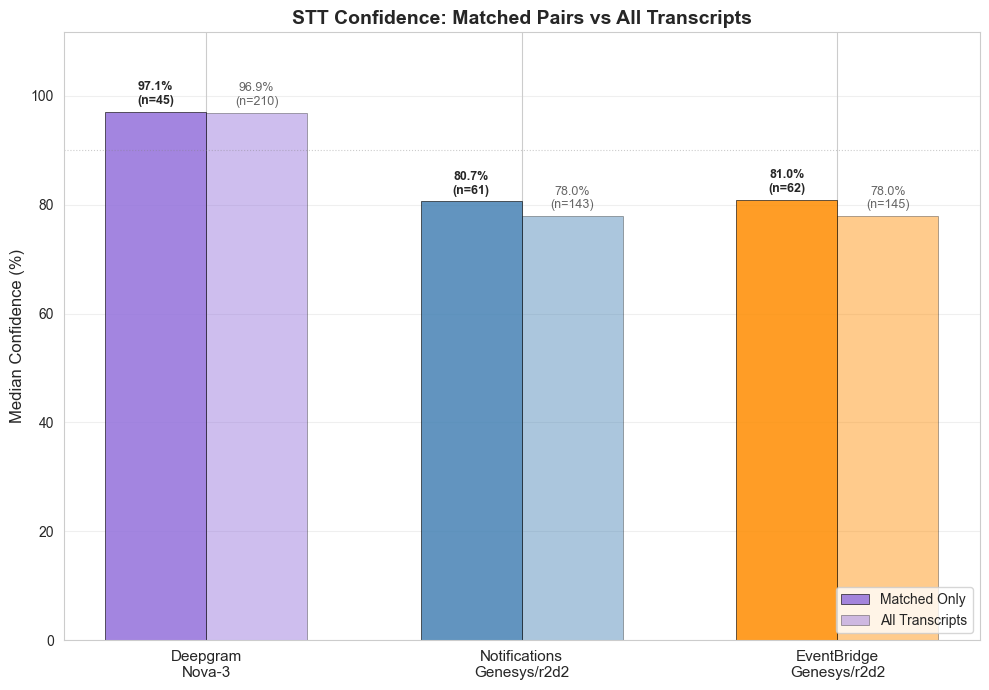

In [5]:
# --- Generate confidence-only chart ---

fig, ax = plt.subplots(figsize=(10, 7))

x_pos = np.arange(len(conf_groups))
bar_width = 0.32

matched_vals = [g[1] for g in conf_groups]
all_vals = [g[2] for g in conf_groups]
bar_colors = [g[3] for g in conf_groups]
matched_n = [g[4] for g in conf_groups]
all_n = [g[5] for g in conf_groups]

bars1 = ax.bar(x_pos - bar_width / 2, matched_vals, bar_width,
               color=bar_colors, edgecolor="black", linewidth=0.5,
               alpha=0.85, label="Matched Only")
bars2 = ax.bar(x_pos + bar_width / 2, all_vals, bar_width,
               color=bar_colors, edgecolor="black", linewidth=0.5,
               alpha=0.45, label="All Transcripts")

# Annotate with values
for i, (mv, av, mn, an) in enumerate(zip(matched_vals, all_vals, matched_n, all_n)):
    ax.text(i - bar_width / 2, mv + 0.8, f"{mv:.1f}%\n(n={mn})",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(i + bar_width / 2, av + 0.8, f"{av:.1f}%\n(n={an})",
            ha="center", va="bottom", fontsize=9, alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels([g[0] for g in conf_groups], fontsize=11)
ax.set_ylabel("Median Confidence (%)", fontsize=12)
ax.set_title("STT Confidence: Matched Pairs vs All Transcripts", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.set_ylim(0, max(max(matched_vals), max(all_vals)) * 1.15)
ax.axhline(y=90, color="gray", linestyle=":", alpha=0.4, linewidth=0.8)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confidence_standalone.png", dpi=SAVE_DPI, bbox_inches="tight")
print(f"Saved to {OUTPUT_DIR / 'confidence_standalone.png'}")
plt.show()